# Fintech Income Analysis (Incremental)

Run this notebook step-by-step to understand behavior before trusting labels.

Phases:
1. Base data truth (one account)
2. Explainable sender rules
3. Account-level income estimate + sensitivity
4. Scale to all accounts

In [1]:
import sys
from pathlib import Path
import pandas as pd

# Make imports work whether notebook is opened from project root or colab/.
candidates = [Path.cwd(), Path.cwd().parent]
project_root = None
for p in candidates:
    if (p / "colab" / "step1_colab_demo.py").exists():
        project_root = p
        break

if project_root is None:
    raise RuntimeError("Could not locate project root containing colab/step1_colab_demo.py")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from colab.step1_colab_demo import (
    load_raw_data,
    build_one_account_sender_profile,
    apply_simple_income_rules,
    estimate_account_income,
    run_incremental_fintech_income,
)

# Human-readable number formatting in notebook tables.
pd.options.display.float_format = '{:,.2f}'.format

print("project_root:", project_root)
print("python:", sys.executable)


project_root: /Users/enkhtuvsin/Work/statement_model
python: /Users/enkhtuvsin/Work/statement_model/.venv/bin/python


In [2]:
# Update account id only; CSV path is auto-resolved.
ACCOUNT_ID = "1"

candidate_csv_paths = [
    project_root / "outputs" / "colab" / "credit_transactions.csv",
    project_root / "credit_transactions.csv",
    Path.cwd() / "credit_transactions.csv",
]

CSV_PATH = None
for p in candidate_csv_paths:
    if p.exists():
        CSV_PATH = str(p)
        break

if CSV_PATH is None:
    raise FileNotFoundError(
        "Could not find credit_transactions.csv. Expected one of: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

print("Using CSV_PATH:", CSV_PATH)


Using CSV_PATH: /Users/enkhtuvsin/Work/statement_model/outputs/colab/credit_transactions.csv


## Phase 1 - Base Data Truth (One Account)

Before any labeling, read this table as behavior evidence for each `sender` in one account.

### What each column means
- `sender`: Counterparty identifier sending credit transactions.
- `freq`: Total number of credit transactions from this sender to the account.
- `avg_amount`: Average transaction amount from this sender.
- `std_amount`: Standard deviation of amount; measures amount volatility.
- `amount_cv`: Amount variability ratio (`std_amount / avg_amount`), easier to compare across senders.
- `max_amount`: Largest single transaction from this sender.
- `unique_days`: Number of distinct calendar days this sender transacted (activity spread).
- `first_date`: First observed transaction date (date-only).
- `last_date`: Last observed transaction date (date-only).
- `unique_months`: Number of distinct active months for this sender.
- `interval_observations`: Number of interval samples available (= `freq - 1`).
- `median_interval_days`: Typical day-gap between sender transactions.
- `interval_std`: Standard deviation of day-gaps; measures timing volatility.
- `total_amount`: Total credited amount from this sender.

### Important note on missing interval values
- If `freq < 2`, interval-based metrics cannot be computed.
- In those cases, `median_interval_days` and `interval_std` are shown as empty (`NaN`) instead of placeholder values.
- These rows are marked later as `unknown_low_evidence` (not forced to regular `other_candidate`).

### Baseline interpretation guide (starting point)
- `std_amount`:
  - near `0` => almost fixed transfer amount
  - moderate => somewhat variable
  - high relative to `avg_amount` => unstable transfer sizes
- `median_interval_days`:
  - around `30 +/- 7` with repeated months => salary-like candidate
  - very short gaps (for example `< 7`) and high frequency => business-flow candidate
  - very large/erratic gaps or sparse frequency => other/irregular candidate
- `interval_std`:
  - low => consistent schedule
  - high => inconsistent schedule

Then use the Phase 1 charts to validate behavior over time:
- **Monthly inflow heatmap (Top 12 senders)** for dense pattern scanning.
- **Small multiples (Top 8 senders)** for readable sender-by-sender trend comparison.

These replace a single multi-line chart, which becomes hard to read when many senders overlap.


Phase 1 - Base profile for account_id=1

Sender Behavior Evidence Table


,sender,freq,avg_amount,std_amount,max_amount,unique_days,first_date,last_date,unique_months,median_interval_days,interval_std,total_amount,amount_cv,interval_observations
27,5020616236,94,"7,765,265.96","16,625,122.27",135000000,60,2025-01-14,2025-09-26,9,0.77,6.33,729935000,2.14,93
11,3655100942,59,"1,362,542.15","1,736,771.83",10000000,30,2025-04-23,2026-01-06,7,0.65,15.33,80389987,1.27,58
84,99102209220,56,"306,767.86","333,249.18",1300000,37,2025-01-01,2026-02-28,13,0.94,12.85,17179000,1.09,55
31,5025475051,53,"452,826.42","1,367,742.82",8000000,45,2025-01-07,2026-02-02,10,1.86,15.84,23999800,3.02,52
12,412147358,33,"1,095,757.58","1,296,521.86",5000000,23,2025-08-29,2026-02-23,4,0.92,22.49,36160000,1.18,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,5022972952,1,"450,000.00",0.00,450000,1,2025-10-15,2025-10-15,1,NaN,NaN,450000,0.00,0
66,5500008255,1,"400,000.00",0.00,400000,1,2025-09-11,2025-09-11,1,NaN,NaN,400000,0.00,0
42,5082003215,1,"300,000.00",0.00,300000,1,2025-11-03,2025-11-03,1,NaN,NaN,300000,0.00,0
36,5037119860,1,"250,000.00",0.00,250000,1,2025-04-14,2025-04-14,1,NaN,NaN,250000,0.00,0


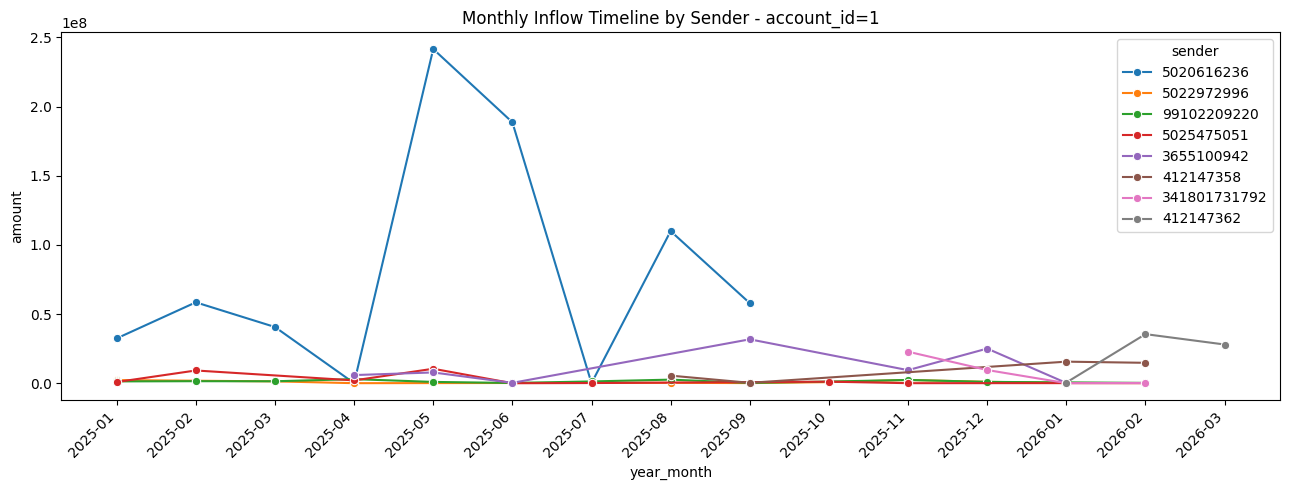

,sender,freq,avg_amount,std_amount,amount_cv,max_amount,unique_days,first_date,last_date,unique_months,median_interval_days,interval_std,interval_observations,total_amount
27,5020616236,94,"7,765,265.96","16,625,122.27",2.14,135000000,60,2025-01-14,2025-09-26,9,0.77,6.33,93,729935000
11,3655100942,59,"1,362,542.15","1,736,771.83",1.27,10000000,30,2025-04-23,2026-01-06,7,0.65,15.33,58,80389987
84,99102209220,56,"306,767.86","333,249.18",1.09,1300000,37,2025-01-01,2026-02-28,13,0.94,12.85,55,17179000
31,5025475051,53,"452,826.42","1,367,742.82",3.02,8000000,45,2025-01-07,2026-02-02,10,1.86,15.84,52,23999800
12,412147358,33,"1,095,757.58","1,296,521.86",1.18,5000000,23,2025-08-29,2026-02-23,4,0.92,22.49,32,36160000
8,341801731792,24,"1,358,541.67","2,151,521.95",1.58,10000000,16,2025-11-19,2026-02-27,4,0.93,10.32,23,32605000
30,5022972996,22,"386,636.36","430,834.58",1.11,1400000,19,2025-01-05,2026-01-06,9,6.12,27.44,21,8506000
13,412147362,21,"3,047,618.14","1,856,775.52",0.61,4999999,13,2026-01-07,2026-03-04,3,0.69,5.98,20,63999981
38,5057100978,19,"25,421.05","20,067.43",0.79,68000,18,2025-01-27,2026-02-18,10,14.20,23.84,18,483000
67,5625424583,13,"8,744,615.38","15,185,987.30",1.74,48700000,8,2025-09-24,2025-10-13,2,0.65,2.74,12,113680000


In [3]:
raw_df = load_raw_data(CSV_PATH)
sender_profile, monthly_timeline = build_one_account_sender_profile(
    raw_df, account_id=ACCOUNT_ID, show_plots=True
)

# Reorder columns for easier reading in Phase 1.
phase1_cols = [
    "sender",
    "freq",
    "avg_amount",
    "std_amount",
    "amount_cv",
    "max_amount",
    "unique_days",
    "first_date",
    "last_date",
    "unique_months",
    "median_interval_days",
    "interval_std",
    "interval_observations",
    "total_amount",
]

sender_profile[phase1_cols].head(20)


## Phase 2 - Explainable Rules
Apply simple monthly-repeat sender heuristic and inspect reasons.

In [23]:
labeled = apply_simple_income_rules(
    sender_profile,
    monthly_presence_min=4,
    interval_days_target=30.0,
    interval_days_tol=7.0,
    salary_freq_min=4,
)
labeled[["sender", "freq", "median_interval_days", "unique_months", "income_type", "reason"]].head(25)



Phase 2 - Explainable Sender Labels


,sender,freq,avg_amount,median_interval_days,unique_months,income_type,reason
27,5020616236,94,"7,765,265.96",0.77,9,sme_candidate,"high_activity sender (freq=94, months=9) but n..."
11,3655100942,59,"1,362,542.15",0.65,7,sme_candidate,"high_activity sender (freq=59, months=7) but n..."
84,99102209220,56,"306,767.86",0.94,13,sme_candidate,"high_activity sender (freq=56, months=13) but ..."
31,5025475051,53,"452,826.42",1.86,10,sme_candidate,"high_activity sender (freq=53, months=10) but ..."
12,412147358,33,"1,095,757.58",0.92,4,sme_candidate,"high_activity sender (freq=33, months=4) but n..."
...,...,...,...,...,...,...,...
73,5890353646,1,"200,000.00",999.00,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."
20,5003687389,1,"100,000.00",999.00,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."
81,5913494780,1,"100,000.00",999.00,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."
26,5019592115,1,"60,000.00",999.00,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."


,sender,freq,median_interval_days,unique_months,income_type,reason
27,5020616236,94,0.77,9,sme_candidate,"high_activity sender (freq=94, months=9) but n..."
11,3655100942,59,0.65,7,sme_candidate,"high_activity sender (freq=59, months=7) but n..."
84,99102209220,56,0.94,13,sme_candidate,"high_activity sender (freq=56, months=13) but ..."
31,5025475051,53,1.86,10,sme_candidate,"high_activity sender (freq=53, months=10) but ..."
12,412147358,33,0.92,4,sme_candidate,"high_activity sender (freq=33, months=4) but n..."
8,341801731792,24,0.93,4,sme_candidate,"high_activity sender (freq=24, months=4) but n..."
30,5022972996,22,6.12,9,sme_candidate,"high_activity sender (freq=22, months=9) but n..."
13,412147362,21,0.69,3,sme_candidate,"high_activity sender (freq=21, months=3) but n..."
38,5057100978,19,14.20,10,sme_candidate,"high_activity sender (freq=19, months=10) but ..."
67,5625424583,13,0.65,2,other_candidate,"irregular pattern (freq=13, months=2, median_i..."


## Phase 3 - Income Estimation (One Account)
Estimate salary/SME/other totals and real income with sensitivity checks.

In [11]:
account_summary, sensitivity = estimate_account_income(labeled)
account_summary



Phase 3 - One Account Income Estimation


,salary_income_est,sme_income_est,other_income_est,real_income_est
0,82143864.0,1.249008e+09,1.071907e+09,1.331152e+09



Phase 3 - Sensitivity Check


,interval_tolerance_days,salary_income_est,sme_income_est,other_income_est,real_income_est
0,5.0,72010000.0,1.249992e+09,1.081057e+09,1.322002e+09
1,7.0,82143864.0,1.249008e+09,1.071907e+09,1.331152e+09
2,10.0,160543864.0,1.177808e+09,1.064707e+09,1.338352e+09


,salary_income_est,sme_income_est,other_income_est,real_income_est
0,82143864.0,1.249008e+09,1.071907e+09,1.331152e+09


In [12]:
sensitivity


,interval_tolerance_days,salary_income_est,sme_income_est,other_income_est,real_income_est
0,5.0,72010000.0,1.249992e+09,1.081057e+09,1.322002e+09
1,7.0,82143864.0,1.249008e+09,1.071907e+09,1.331152e+09
2,10.0,160543864.0,1.177808e+09,1.064707e+09,1.338352e+09


## Phase 4 - Scale to All Accounts
Apply validated logic account-by-account with explainable outputs.

In [13]:
results = run_incremental_fintech_income(
    csv_path=CSV_PATH,
    account_id=ACCOUNT_ID,
    show_plots=False,
    interval_days_tol=7.0,
)
results.keys()



Phase 1 - Base profile for account_id=1

Sender Behavior Evidence Table


,sender,freq,avg_amount,std_amount,max_amount,unique_days,first_date,last_date,unique_months,median_interval_days,interval_std,total_amount
27,5020616236,94,7.765266e+06,1.662512e+07,135000000,60,2025-01-14 16:01:00+08:00,2025-09-26 14:48:00+08:00,9,0.774306,6.332317,729935000
11,3655100942,59,1.362542e+06,1.736772e+06,10000000,30,2025-04-23 15:02:00+08:00,2026-01-06 15:37:00+08:00,7,0.653125,15.330541,80389987
84,99102209220,56,3.067679e+05,3.332492e+05,1300000,37,2025-01-01 15:18:00+08:00,2026-02-28 11:06:00+08:00,13,0.938194,12.853095,17179000
31,5025475051,53,4.528264e+05,1.367743e+06,8000000,45,2025-01-07 16:50:00+08:00,2026-02-02 20:09:00+08:00,10,1.860069,15.842304,23999800
12,412147358,33,1.095758e+06,1.296522e+06,5000000,23,2025-08-29 15:10:00+08:00,2026-02-23 18:16:00+08:00,4,0.923611,22.489015,36160000
...,...,...,...,...,...,...,...,...,...,...,...,...
29,5022972952,1,4.500000e+05,0.000000e+00,450000,1,2025-10-15 12:38:00+08:00,2025-10-15 12:38:00+08:00,1,999.000000,999.000000,450000
66,5500008255,1,4.000000e+05,0.000000e+00,400000,1,2025-09-11 15:37:00+08:00,2025-09-11 15:37:00+08:00,1,999.000000,999.000000,400000
42,5082003215,1,3.000000e+05,0.000000e+00,300000,1,2025-11-03 17:47:00+08:00,2025-11-03 17:47:00+08:00,1,999.000000,999.000000,300000
36,5037119860,1,2.500000e+05,0.000000e+00,250000,1,2025-04-14 15:56:00+08:00,2025-04-14 15:56:00+08:00,1,999.000000,999.000000,250000



Phase 2 - Explainable Sender Labels


,sender,freq,avg_amount,median_interval_days,unique_months,income_type,reason
27,5020616236,94,7.765266e+06,0.774306,9,sme_candidate,"high_activity sender (freq=94, months=9) but n..."
11,3655100942,59,1.362542e+06,0.653125,7,sme_candidate,"high_activity sender (freq=59, months=7) but n..."
84,99102209220,56,3.067679e+05,0.938194,13,sme_candidate,"high_activity sender (freq=56, months=13) but ..."
31,5025475051,53,4.528264e+05,1.860069,10,sme_candidate,"high_activity sender (freq=53, months=10) but ..."
12,412147358,33,1.095758e+06,0.923611,4,sme_candidate,"high_activity sender (freq=33, months=4) but n..."
...,...,...,...,...,...,...,...
73,5890353646,1,2.000000e+05,999.000000,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."
20,5003687389,1,1.000000e+05,999.000000,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."
81,5913494780,1,1.000000e+05,999.000000,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."
26,5019592115,1,6.000000e+04,999.000000,1,other_candidate,"irregular pattern (freq=1, months=1, median_in..."



Phase 3 - One Account Income Estimation


...


Phase 4 - Final Sender Dataset (All Accounts)


,sender,freq,avg_amount,std_amount,interval_std,unique_days,max_amount,income_type,reason,account_id
0,5625424583,13,8.744615e+06,1.518599e+07,2.736116,8,48700000,other_candidate,"irregular pattern (freq=13, months=2, median_i...",1
1,5176017202,7,1.028571e+06,5.437962e+05,72.878253,7,1700000,other_candidate,"irregular pattern (freq=7, months=6, median_in...",1
2,5925696646,6,2.016667e+04,1.664232e+04,51.509846,6,50000,other_candidate,"irregular pattern (freq=6, months=4, median_in...",1
3,3455156778,5,1.000000e+07,1.118034e+07,40.977856,3,30000000,other_candidate,"irregular pattern (freq=5, months=3, median_in...",1
4,5720537278,5,2.860000e+06,4.037078e+06,126.044239,4,10000000,other_candidate,"irregular pattern (freq=5, months=3, median_in...",1
...,...,...,...,...,...,...,...,...,...,...
75,3655100942,59,1.362542e+06,1.736772e+06,15.330541,30,10000000,sme_candidate,"high_activity sender (freq=59, months=7) but n...",1
76,99102209220,56,3.067679e+05,3.332492e+05,12.853095,37,1300000,sme_candidate,"high_activity sender (freq=56, months=13) but ...",1
77,5025475051,53,4.528264e+05,1.367743e+06,15.842304,45,8000000,sme_candidate,"high_activity sender (freq=53, months=10) but ...",1
78,412147358,33,1.095758e+06,1.296522e+06,22.489015,23,5000000,sme_candidate,"high_activity sender (freq=33, months=4) but n...",1



Phase 4 - Account Income Summary (All Accounts)


,account_id,salary_income_est,sme_income_est,other_income_est,real_income_est
0,1,82143864.0,1.249008e+09,1.071907e+09,1.331152e+09
9,10,0.0,1.380300e+07,1.738632e+07,1.380300e+07
10,11,69180000.0,8.150000e+07,3.025609e+08,1.506800e+08
11,12,0.0,1.286600e+07,1.611016e+08,1.286600e+07
12,13,0.0,6.405000e+05,8.910095e+06,6.405000e+05
13,14,0.0,1.474294e+07,3.883635e+07,1.474294e+07
14,15,0.0,7.565200e+07,4.708829e+07,7.565200e+07
15,16,0.0,0.000000e+00,9.000000e+05,0.000000e+00
16,17,3200000.0,3.377470e+07,4.987348e+07,3.697470e+07
17,18,0.0,3.804200e+07,2.973283e+08,3.804200e+07


dict_keys(['raw_data', 'phase1_sender_profile', 'phase1_monthly_timeline', 'phase2_labeled_senders', 'phase3_account_income_summary', 'phase3_sensitivity', 'phase4_final_sender_dataset', 'phase4_account_income_summary_all'])

In [14]:
results["phase4_account_income_summary_all"].head(20)


,account_id,salary_income_est,sme_income_est,other_income_est,real_income_est
0,1,82143864.0,1.249008e+09,1.071907e+09,1.331152e+09
9,10,0.0,1.380300e+07,1.738632e+07,1.380300e+07
10,11,69180000.0,8.150000e+07,3.025609e+08,1.506800e+08
11,12,0.0,1.286600e+07,1.611016e+08,1.286600e+07
12,13,0.0,6.405000e+05,8.910095e+06,6.405000e+05
13,14,0.0,1.474294e+07,3.883635e+07,1.474294e+07
14,15,0.0,7.565200e+07,4.708829e+07,7.565200e+07
15,16,0.0,0.000000e+00,9.000000e+05,0.000000e+00
16,17,3200000.0,3.377470e+07,4.987348e+07,3.697470e+07
17,18,0.0,3.804200e+07,2.973283e+08,3.804200e+07


In [15]:
results["phase4_final_sender_dataset"].head(30)


,sender,freq,avg_amount,std_amount,interval_std,unique_days,max_amount,income_type,reason,account_id
0,5625424583,13,8.744615e+06,1.518599e+07,2.736116,8,48700000,other_candidate,"irregular pattern (freq=13, months=2, median_i...",1
1,5176017202,7,1.028571e+06,5.437962e+05,72.878253,7,1700000,other_candidate,"irregular pattern (freq=7, months=6, median_in...",1
2,5925696646,6,2.016667e+04,1.664232e+04,51.509846,6,50000,other_candidate,"irregular pattern (freq=6, months=4, median_in...",1
3,3455156778,5,1.000000e+07,1.118034e+07,40.977856,3,30000000,other_candidate,"irregular pattern (freq=5, months=3, median_in...",1
4,5720537278,5,2.860000e+06,4.037078e+06,126.044239,4,10000000,other_candidate,"irregular pattern (freq=5, months=3, median_in...",1
5,100900011051,5,8.550158e+05,1.876292e+06,2.107581,5,4211344,other_candidate,"irregular pattern (freq=5, months=5, median_in...",1
6,2905164746,5,5.600000e+05,5.594640e+05,40.908618,5,1500000,other_candidate,"irregular pattern (freq=5, months=5, median_in...",1
7,5070508130,4,3.812500e+07,1.371207e+07,9.770265,4,50000000,other_candidate,"irregular pattern (freq=4, months=3, median_in...",1
8,471022214,4,4.999999e+06,0.000000e+00,0.000327,1,4999999,other_candidate,"irregular pattern (freq=4, months=1, median_in...",1
9,3215131527,3,3.416667e+07,1.371207e+07,4.029167,3,50000000,other_candidate,"irregular pattern (freq=3, months=3, median_in...",1


## Optional Export

In [ ]:
results["phase4_account_income_summary_all"].to_csv("phase4_account_income_summary_all.csv", index=False)
results["phase4_final_sender_dataset"].to_csv("phase4_final_sender_dataset.csv", index=False)
print("Saved: phase4_account_income_summary_all.csv, phase4_final_sender_dataset.csv")
